# Phase 3: Complete Evaluation — Pure vs FST-Boosted Models

This notebook performs the full evaluation pipeline:

1. **Pure Baseline** — Models fine-tuned on raw text, evaluated on raw text.
2. **FST-Boosted** — Models fine-tuned on FST-segmented text, evaluated on FST-segmented text.
3. **Split Analysis** — Short text (≤60 chars) vs Long text (>60 chars).
4. **False Positive Analysis** — How many real humans get falsely flagged as AI.
5. **Publication-Ready Visualizations** — Bar charts comparing all metrics.

In [1]:
import os
import sys

# Must be set before torch/numpy import or libiomp5md.dll crashes on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HOME"] = "D:/roberta/hf_cache"
os.environ["HF_DATASETS_IN_MEMORY_MAX_SIZE"] = "0"

import pandas as pd
import numpy as np
import torch
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.insert(0, 'D:/roberta')
from fst_analyzer import fst_analyzer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

Device: cuda


## 1. Load & Prepare Data

In [2]:
DATA_DIR = "D:/roberta/data"

df_human = pd.read_csv(os.path.join(DATA_DIR, "kazsandra_human_train.csv"))
df_human["label"] = 0

# Native Kazakh AI dataset (paraphrase + social-media posts).
# Replaces the old review-style ai_train_v2.csv.
df_ai = pd.read_csv(os.path.join(DATA_DIR, "ai_train_native_kk.csv"))
df_ai["label"] = 1

df_train = pd.concat([df_human[["text", "label"]], df_ai[["text", "label"]]])
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_train["text"] = df_train["text"].astype(str)

df_eval = pd.read_csv(os.path.join(DATA_DIR, "heldout_test.csv"))
df_eval["text"] = df_eval["text"].astype(str)

# FST-processed versions for the FST column
df_train_fst = df_train.copy()
df_train_fst["text"] = df_train_fst["text"].apply(fst_analyzer.analyze_and_segment)

df_eval_fst = df_eval.copy()
df_eval_fst["text"] = df_eval_fst["text"].apply(fst_analyzer.analyze_and_segment)

# Split eval by original text length (before FST)
df_eval["text_len"] = df_eval["text"].apply(len)
short_mask = df_eval["text_len"] <= 60

print(f"AI training data:    ai_train_native_kk.csv  ({len(df_ai)} rows)")
print(f"Human training data: kazsandra_human_train.csv  ({len(df_human)} rows)")
print(f"Total training:      {len(df_train)}")
print(f"Test samples:        {len(df_eval)}")
print(f"  Short (<=60 chars): {short_mask.sum()}")
print(f"  Long  (>60 chars):  {(~short_mask).sum()}")
print(f"\nFST example:")
print(f"  Raw:  {df_train['text'].iloc[0][:80]}")
print(f"  FST:  {df_train_fst['text'].iloc[0][:80]}")

AI training data:    ai_train_native_kk.csv  (4832 rows)
Human training data: kazsandra_human_train.csv  (5000 rows)
Total training:      9832
Test samples:        3842
  Short (<=60 chars): 1758
  Long  (>60 chars):  2084

FST example:
  Raw:  Өте ұнады менде екі тик ток
  FST:  Өте ұна -ды ме -нде екі тик ток


## 2. Training & Evaluation Helpers

In [3]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds, zero_division=0)}

def get_predictions(model, tokenizer, texts, batch_size=32):
    """GPU inference — ~10-20x faster than CPU for transformer models."""
    model = model.to(device)
    model.eval()
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=128, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    del inputs
    torch.cuda.empty_cache()
    return np.array(preds)

def train_and_evaluate(name, hf_path, train_df, eval_df, save_dir):
    """Train a model on GPU, evaluate on GPU."""
    if os.path.exists(os.path.join(save_dir, "config.json")):
        print(f"  Loading existing model from {save_dir}")
        tokenizer = AutoTokenizer.from_pretrained(save_dir)
        model = AutoModelForSequenceClassification.from_pretrained(save_dir)
    else:
        print(f"  Training from scratch: {hf_path}")
        tokenizer = AutoTokenizer.from_pretrained(hf_path)

        def tokenize(batch):
            return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

        split = Dataset.from_pandas(train_df).train_test_split(test_size=0.1, seed=42)
        tok_train = split["train"].map(tokenize, batched=True)
        tok_val   = split["test"].map(tokenize, batched=True)

        model = AutoModelForSequenceClassification.from_pretrained(hf_path, num_labels=2)

        args = TrainingArguments(
            output_dir=save_dir,
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            report_to="none",
            fp16=torch.cuda.is_available(),
        )

        trainer = Trainer(model=model, args=args,
                          train_dataset=tok_train, eval_dataset=tok_val,
                          compute_metrics=compute_metrics)
        trainer.train()
        trainer.save_model(save_dir)
        tokenizer.save_pretrained(save_dir)

    print(f"  Predicting on {device.upper()}...")
    preds = get_predictions(model, tokenizer, eval_df["text"])
    del model
    torch.cuda.empty_cache()
    return preds

## 3. Run Full Evaluation Pipeline
This trains (or loads) all 4 models in both Pure and FST modes, then collects predictions.

In [4]:
MODELS = [
    ("mBERT",      "bert-base-multilingual-cased"),
    ("XLM-R",      "xlm-roberta-base"),
    ("KazBERT",    "Eraly-ml/KazBERT"),
    ("KazRoBERTa", "kz-transformers/kaz-roberta-conversational"),
]

all_results = []

for name, hf_path in MODELS:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Save dirs use _native suffix so old ai_train_v2 models are not overwritten
    pure_dir = os.path.join(DATA_DIR, f"pure_native_{name}")
    fst_dir  = os.path.join(DATA_DIR, f"fst_native_{name}")

    print(f"[PURE]")
    pure_preds = train_and_evaluate(name, hf_path, df_train, df_eval, pure_dir)

    print(f"[FST]")
    fst_preds = train_and_evaluate(name, hf_path, df_train_fst, df_eval_fst, fst_dir)

    labels = df_eval["label"].values

    for mode, preds in [("Pure", pure_preds), ("FST", fst_preds)]:
        acc_all   = accuracy_score(labels, preds) * 100
        f1_all    = f1_score(labels, preds, zero_division=0) * 100
        acc_short = accuracy_score(labels[short_mask], preds[short_mask]) * 100
        acc_long  = accuracy_score(labels[~short_mask], preds[~short_mask]) * 100
        cm_short  = confusion_matrix(labels[short_mask], preds[short_mask], labels=[0, 1])
        fp_short  = cm_short[0][1] if cm_short.shape == (2, 2) else 0

        all_results.append({
            "Model": name, "Mode": mode,
            "Acc_All": acc_all, "F1_All": f1_all,
            "Acc_Short": acc_short, "Acc_Long": acc_long,
            "FP_Short": fp_short,
        })

df_results = pd.DataFrame(all_results)
print("\n\nDone! All results collected.")
df_results


  mBERT
[PURE]
  Training from scratch: bert-base-multilingual-cased


Map:   0%|          | 0/8848 [00:00<?, ? examples/s]

Map:   0%|          | 0/984 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1659 [00:00<?, ?it/s]

...

  0%|          | 0/31 [00:00<?, ?it/s]

{'eval_loss': 0.20940184593200684, 'eval_accuracy': 0.959349593495935, 'eval_f1': 0.956989247311828, 'eval_runtime': 0.5453, 'eval_samples_per_second': 1804.567, 'eval_steps_per_second': 56.851, 'epoch': 2.0}
{'loss': 0.0374, 'grad_norm': 6.615546226501465, 'learning_rate': 4.792043399638336e-06, 'epoch': 2.71}


  0%|          | 0/31 [00:00<?, ?it/s]

{'eval_loss': 0.28055906295776367, 'eval_accuracy': 0.9563008130081301, 'eval_f1': 0.9539121114683816, 'eval_runtime': 0.5493, 'eval_samples_per_second': 1791.487, 'eval_steps_per_second': 56.439, 'epoch': 3.0}
{'train_runtime': 79.8797, 'train_samples_per_second': 332.3, 'train_steps_per_second': 20.769, 'train_loss': 0.10547330438408095, 'epoch': 3.0}
  Predicting on CUDA...


Done! All results collected.


,Model,Mode,Acc_All,F1_All,Acc_Short,Acc_Long,FP_Short
0,mBERT,Pure,95.419053,95.463918,94.425484,96.257198,58
1,mBERT,FST,93.623113,93.706653,92.832765,94.289827,70
2,XLM-R,Pure,95.445081,95.523152,94.084187,96.593090,67
3,XLM-R,FST,94.351900,94.499366,93.230944,95.297505,83
4,KazBERT,Pure,94.586153,94.633643,93.515358,95.489443,63
5,KazBERT,FST,94.560125,94.625868,93.344710,95.585413,65
6,KazRoBERTa,Pure,96.095783,96.149897,95.051195,96.976967,53
7,KazRoBERTa,FST,96.069755,96.072822,94.994312,96.976967,36


## 4. Results Table

In [5]:
display(df_results.style.format({
    "Acc_All": "{:.2f}%", "F1_All": "{:.2f}%",
    "Acc_Short": "{:.2f}%", "Acc_Long": "{:.2f}%",
    "FP_Short": "{:.0f}"
}).set_caption("Complete Evaluation Results"))

,Model,Mode,Acc_All,F1_All,Acc_Short,Acc_Long,FP_Short
0,mBERT,Pure,95.42%,95.46%,94.43%,96.26%,58
1,mBERT,FST,93.62%,93.71%,92.83%,94.29%,70
2,XLM-R,Pure,95.45%,95.52%,94.08%,96.59%,67
3,XLM-R,FST,94.35%,94.50%,93.23%,95.30%,83
4,KazBERT,Pure,94.59%,94.63%,93.52%,95.49%,63
5,KazBERT,FST,94.56%,94.63%,93.34%,95.59%,65
6,KazRoBERTa,Pure,96.10%,96.15%,95.05%,96.98%,53
7,KazRoBERTa,FST,96.07%,96.07%,94.99%,96.98%,36


## 5. Short Text Accuracy — Pure vs FST

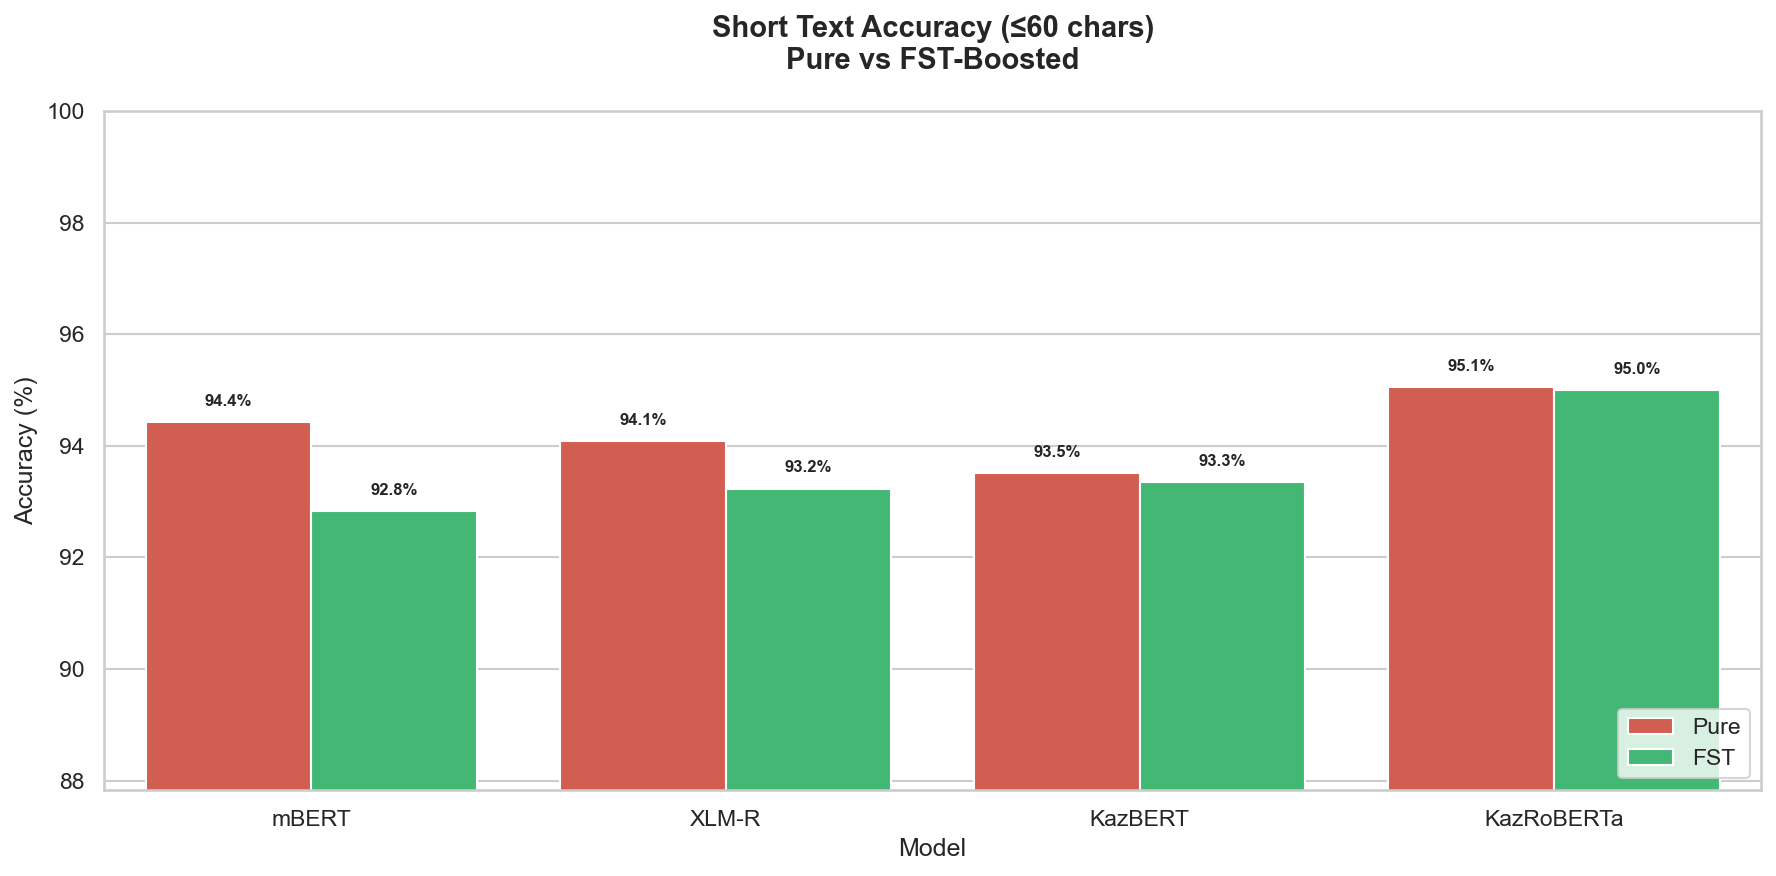

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = {"Pure": "#E74C3C", "FST": "#2ECC71"}
sns.barplot(data=df_results, x="Model", y="Acc_Short", hue="Mode",
            palette=palette, hue_order=["Pure", "FST"], ax=ax)
ax.set_title("Short Text Accuracy (≤60 chars)\nPure vs FST-Boosted", pad=20, fontweight="bold", fontsize=14)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(max(80, df_results["Acc_Short"].min() - 5), 100)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2., h),
                    ha="center", va="center", xytext=(0, 10), textcoords="offset points", fontweight="bold", fontsize=8)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "chart_short_text_acc.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. False Positive Reduction on Short Text

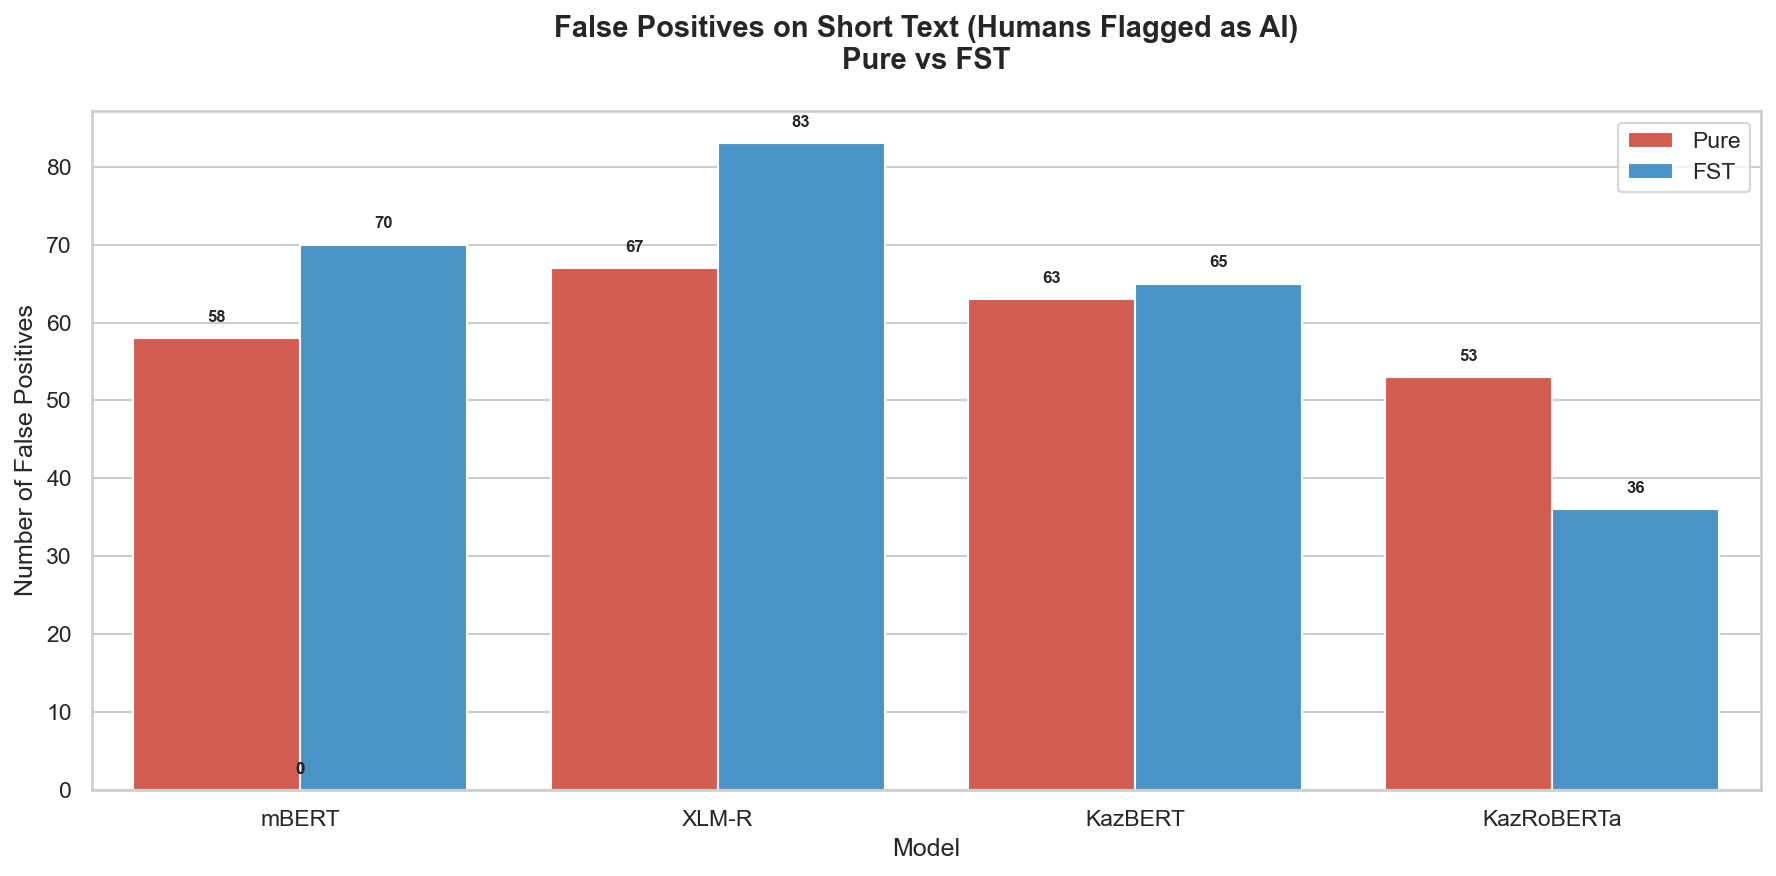

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = {"Pure": "#E74C3C", "FST": "#3498DB"}
sns.barplot(data=df_results, x="Model", y="FP_Short", hue="Mode",
            palette=palette, hue_order=["Pure", "FST"], ax=ax)
ax.set_title("False Positives on Short Text (Humans Flagged as AI)\nPure vs FST", pad=20, fontweight="bold", fontsize=14)
ax.set_ylabel("Number of False Positives")

for p in ax.patches:
    h = p.get_height()
    if h >= 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width()/2., h),
                    ha="center", va="center", xytext=(0, 10), textcoords="offset points", fontweight="bold", fontsize=8)

ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "chart_false_positives.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. FP Reduction Rate: Pure → FST

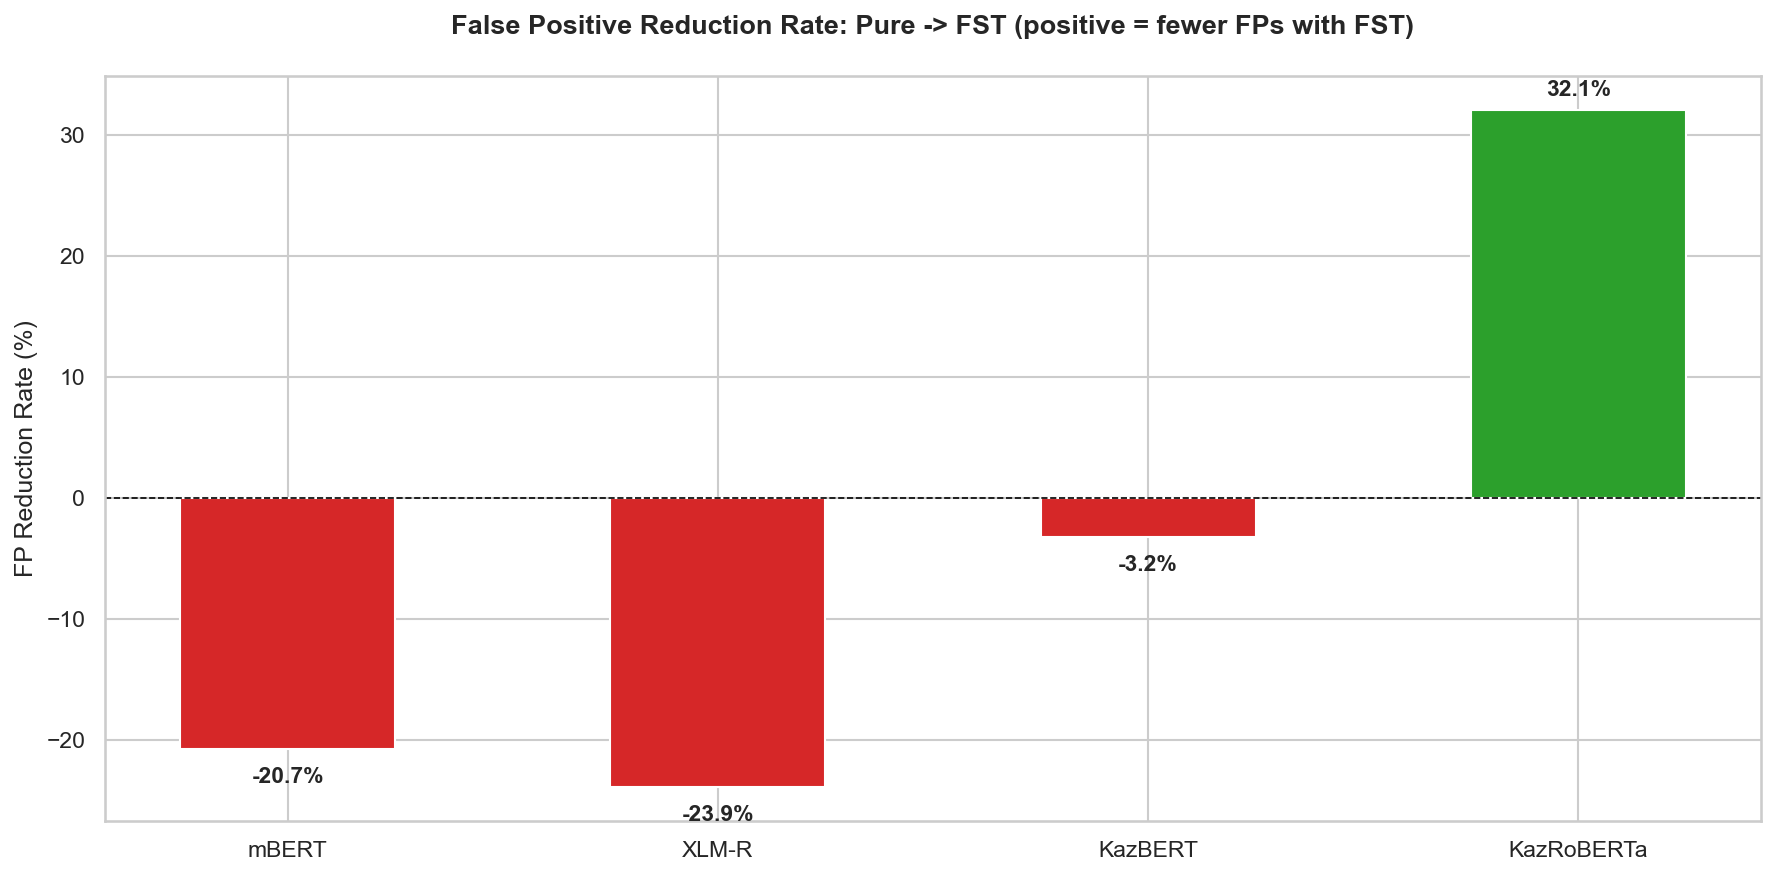

In [15]:
pure = df_results[df_results["Mode"]=="Pure"].set_index("Model")
fst  = df_results[df_results["Mode"]=="FST"].set_index("Model")
models_order = ["mBERT", "XLM-R", "KazBERT", "KazRoBERTa"]
fp_red = {m: 100*(pure.loc[m,"FP_Short"] - fst.loc[m,"FP_Short"]) / pure.loc[m,"FP_Short"] for m in models_order}

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in fp_red.values()]
bars = ax.bar(models_order, fp_red.values(), color=bar_colors, width=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("False Positive Reduction Rate: Pure -> FST (positive = fewer FPs with FST)",
             pad=20, fontweight="bold", fontsize=13)
ax.set_ylabel("FP Reduction Rate (%)")
for bar, v in zip(bars, fp_red.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + (0.8 if v >= 0 else -1.5),
            f"{v:.1f}%", ha="center",
            va="bottom" if v >= 0 else "top",
            fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "chart_fp_reduction.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Overall Accuracy — Pure vs FST

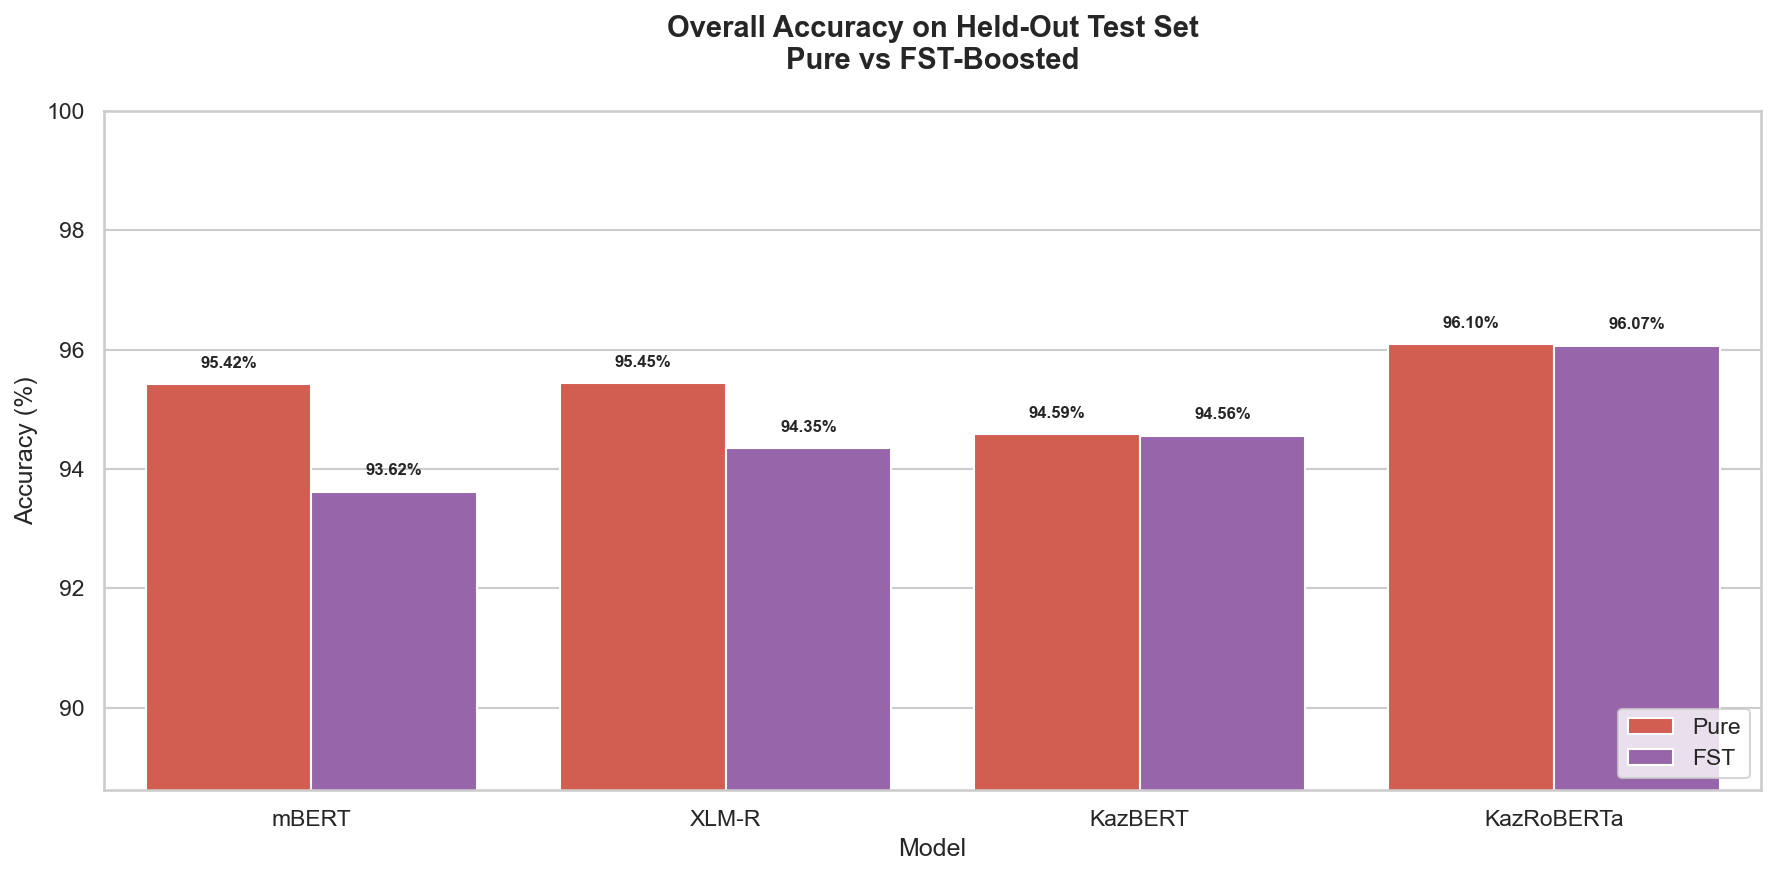

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = {"Pure": "#E74C3C", "FST": "#9B59B6"}
sns.barplot(data=df_results, x="Model", y="Acc_All", hue="Mode",
            palette=palette, hue_order=["Pure", "FST"], ax=ax)
ax.set_title("Overall Accuracy on Held-Out Test Set\nPure vs FST-Boosted", pad=20, fontweight="bold", fontsize=14)
ax.set_ylabel("Accuracy (%)")
# Dynamic ylim so native models (which can be ~68%) are visible, not clipped
ax.set_ylim(max(60, df_results["Acc_All"].min() - 5), 100)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}%", (p.get_x() + p.get_width()/2., h),
                    ha="center", va="center", xytext=(0, 10), textcoords="offset points", fontweight="bold", fontsize=8)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "chart_overall_acc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
df_results.to_csv(os.path.join(DATA_DIR, "full_evaluation_results.csv"), index=False)
df_results.to_json(os.path.join(DATA_DIR, "full_evaluation_results.json"), orient="records", indent=2)
print("Results saved.")
print(f"\nFinal table ({len(df_results)} rows — {df_results['Mode'].value_counts().to_dict()}):")
display(df_results.style.format({
    "Acc_All": "{:.2f}%", "F1_All": "{:.2f}%",
    "Acc_Short": "{:.2f}%", "Acc_Long": "{:.2f}%",
    "FP_Short": "{:.0f}"
}).set_caption("Complete Evaluation — Pure vs FST vs Native"))

Results saved.

Final table (8 rows — {'Pure': 4, 'FST': 4}):


,Model,Mode,Acc_All,F1_All,Acc_Short,Acc_Long,FP_Short
0,mBERT,Pure,95.42%,95.46%,94.43%,96.26%,58
1,mBERT,FST,93.62%,93.71%,92.83%,94.29%,70
2,XLM-R,Pure,95.45%,95.52%,94.08%,96.59%,67
3,XLM-R,FST,94.35%,94.50%,93.23%,95.30%,83
4,KazBERT,Pure,94.59%,94.63%,93.52%,95.49%,63
5,KazBERT,FST,94.56%,94.63%,93.34%,95.59%,65
6,KazRoBERTa,Pure,96.10%,96.15%,95.05%,96.98%,53
7,KazRoBERTa,FST,96.07%,96.07%,94.99%,96.98%,36
